# Comparing the results of multiple 
This document 

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

In [2]:
from os import listdir
from os.path import isfile, join


Importing the collected data

In [3]:
#from google.colab import files
#uploaded = files.upload()
#%ls

In [4]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.show()
  #plt.savefig(filename) 

## LSTM Model


### Model Definition

In [5]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        #self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        #self.fc = nn.Linear(128, num_classes) #fully connected last layer

        #self.relu = nn.ReLU()

        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        #hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        #out = self.relu(hn)
        #out = self.fc_1(out) #first Dense
        #out = self.relu(out) #relu
        #out = self.fc(out) #Final Output
        out = self.fc(output[:,-1,:])
        return out

Model Parameters

In [6]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.01 #0.001 lr

input_size = 1 #number of features
hidden_size = 16 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

look_back = 12


In [7]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [8]:
mm = MinMaxScaler()
ss = StandardScaler()

In [9]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.8)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [10]:
def process_data(df):

  # shift the prices
  #df2 = df.copy(deep=True)
  #df2['priceUsd'] = df2.priceUsd.shift(-1)
  #df = df.iloc[1:-1]
  #df2 = df2.iloc[1:-1]
  # split into x and y
  x = df.iloc[:, :1]
  x_raw = ss.fit_transform(x)
  #x_raw = x_pre.to_numpy()
  x_2d = []

  for index in range(len(x_raw) - look_back):
    x_2d.append(x_raw[index: index + look_back])

  x_2d = np.array(x_2d)
  #y = df2.iloc[:, 0:1]
  y = df.iloc[:,-1:]
  
  #print(x_2d[:5])

  # transform the data
  #x_ss = ss.fit_transform(x)
  y_mm = mm.fit_transform(y)
  

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_2d, y_mm)
  # reshape tensors 
  #x_train = torch.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
  #x_test = torch.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1])) 

  return x_train, x_test, y_train, y_test, cutoff

In [11]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
def classify(predict, direction):
    results = []
    for i in range(len(predict)):
        if (predict[i] > predict[i-1]*1.000):
            results.append("positive")
        elif (predict[i] <= predict[i-1]*1.000):
            results.append("negative")
        else:
            results.append("neutral")
    results.append("neutral")
    totalcorrect = 0
    neutralcount = 0
    neutralcorrect = 0
    positivecorrect = 0
    negativecorrect = 0
    positivecount = 0
    negativecount = 0
    neutralprediction = 0
    for i in range(len(predict)):
        if results[i] == "neutral":
            neutralprediction += 1
        if direction[i] == "positive":
            positivecount += 1
        elif direction[i] == "negative":
            negativecount += 1
        elif direction[i] == "neutral":
            neutralcount += 1
        if results[i] == direction[i]:
            totalcorrect += 1
            if results[i] == "negative":
                negativecorrect += 1
            elif results[i] == "positive":
                positivecorrect += 1
            elif results[i] == "neutral":
                neutralcorrect += 1
    #print("number tested: ", len(predict))
    #print("accuracy: ", count/len(predict))
    print("% positive: ", positivecount/len(predict))
    print("% negative: ", negativecount/len(predict))
    print("% neutral: ", neutralcount/len(predict))
    print("positive correct: ", positivecorrect/positivecount)
    print("negative correct: ", negativecorrect/negativecount)
    #print("neutral correct: ", neutralcorrect/neutralcount)
    #print("neutral prediction: ", neutralprediction/len(predict))

    return totalcorrect/len(predict)

binance-coin30m.csv
Epoch: 0, loss: 0.07332
Epoch: 100, loss: 0.00015
Epoch: 200, loss: 0.00013
Epoch: 300, loss: 0.00013
Epoch: 400, loss: 0.00012
Epoch: 500, loss: 0.00011
Epoch: 600, loss: 0.00010
Epoch: 700, loss: 0.00023
Epoch: 800, loss: 0.00006
Epoch: 900, loss: 0.00007
% positive:  0.505838792366847
% negative:  0.49416120763315297
% neutral:  0.0
positive correct:  0.6492117117117117
negative correct:  0.622478386167147
0.6360011392765594


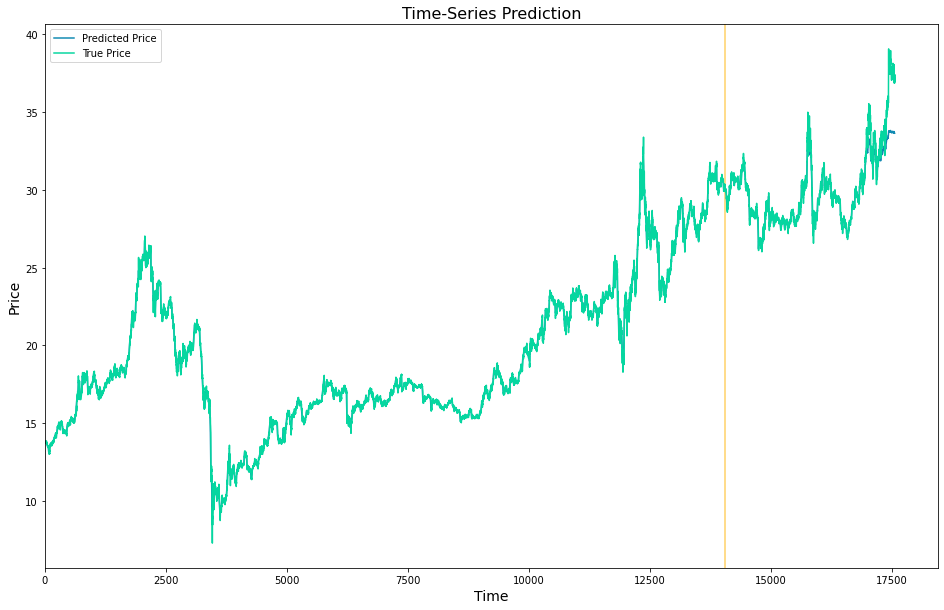

bitcoin-cash30m.csv
Epoch: 0, loss: 0.07920
Epoch: 100, loss: 0.00028
Epoch: 200, loss: 0.00024
Epoch: 300, loss: 0.00022
Epoch: 400, loss: 0.00019
Epoch: 500, loss: 0.00016
Epoch: 600, loss: 0.00009
Epoch: 700, loss: 0.00036
Epoch: 800, loss: 0.00009
Epoch: 900, loss: 0.00009
% positive:  0.5015665052691541
% negative:  0.4984334947308459
% neutral:  0.0
positive correct:  0.5905735377626349
negative correct:  0.5754285714285714
0.5830247792651666


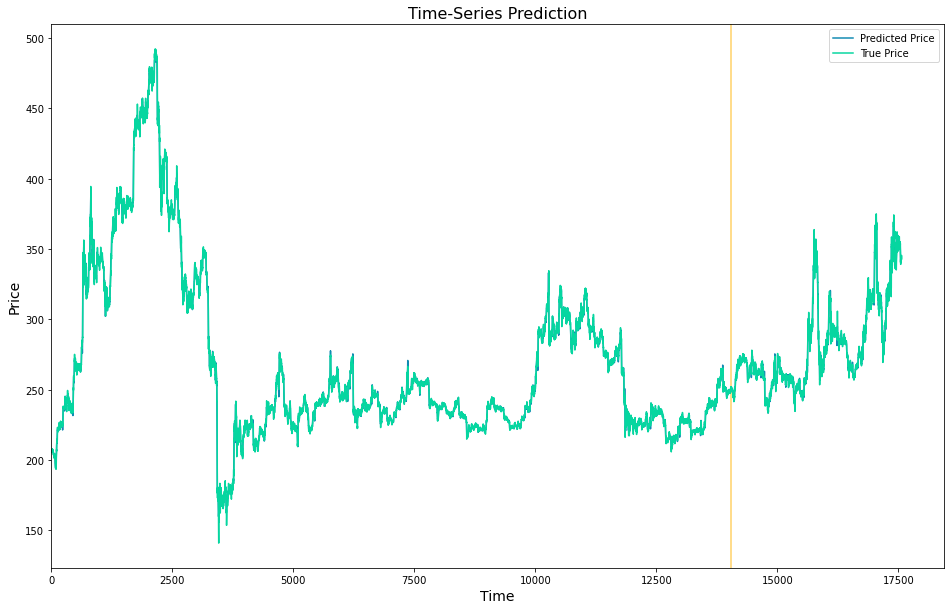

bitcoin30m.csv
Epoch: 0, loss: 0.15961
Epoch: 100, loss: 0.00002
Epoch: 200, loss: 0.00002
Epoch: 300, loss: 0.00002
Epoch: 400, loss: 0.00002
Epoch: 500, loss: 0.00002
Epoch: 600, loss: 0.00002
Epoch: 700, loss: 0.00002
Epoch: 800, loss: 0.00002
Epoch: 900, loss: 0.00002
% positive:  0.5306180575334662
% negative:  0.46938194246653375
% neutral:  0.0
positive correct:  0.5802469135802469
negative correct:  0.41444174757281554
0.5024209626886926


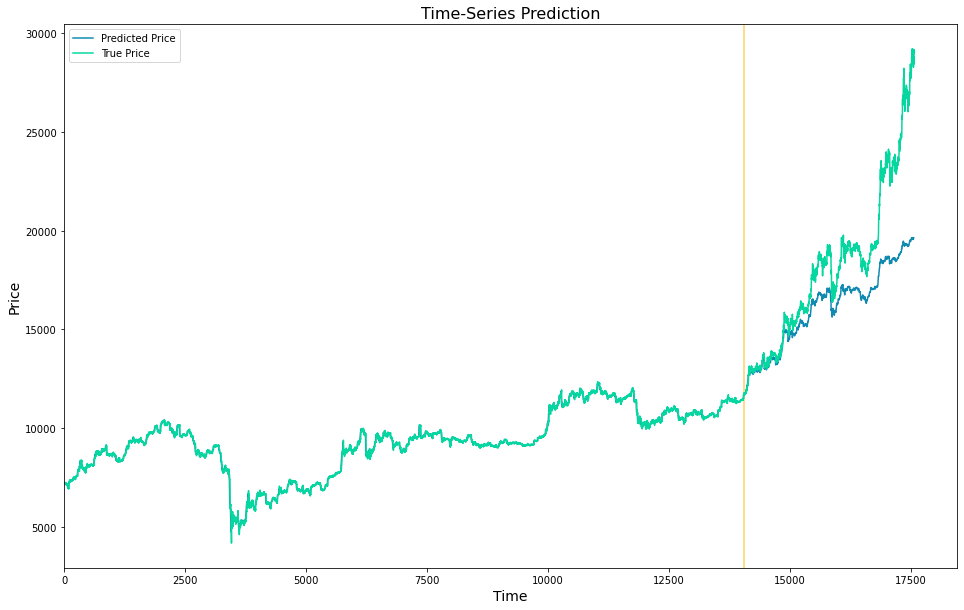

cardano30m.csv
Epoch: 0, loss: 0.11260
Epoch: 100, loss: 0.00012
Epoch: 200, loss: 0.00008
Epoch: 300, loss: 0.00008
Epoch: 400, loss: 0.00008
Epoch: 500, loss: 0.00008
Epoch: 600, loss: 0.00007
Epoch: 700, loss: 0.00007
Epoch: 800, loss: 0.00007
Epoch: 900, loss: 0.00006
% positive:  0.5009968669894617
% negative:  0.49900313301053834
% neutral:  0.0
positive correct:  0.557703240477544
negative correct:  0.5388127853881278
0.5482768442039305


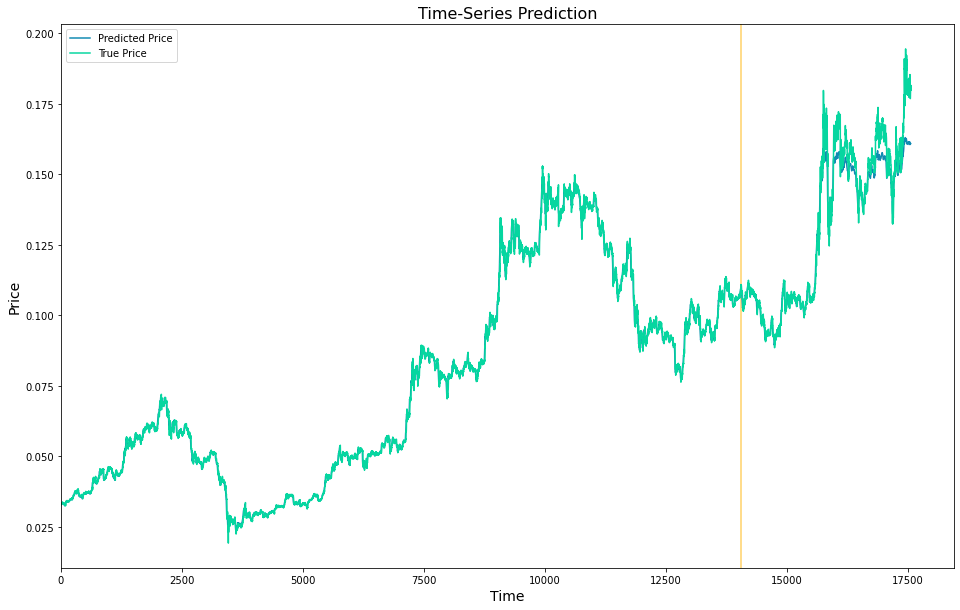

chainlink30m.csv
Epoch: 0, loss: 0.12557
Epoch: 100, loss: 0.00022
Epoch: 200, loss: 0.00014
Epoch: 300, loss: 0.00013
Epoch: 400, loss: 0.00012
Epoch: 500, loss: 0.00012
Epoch: 600, loss: 0.00011
Epoch: 700, loss: 0.00010
Epoch: 800, loss: 0.00010
Epoch: 900, loss: 0.00009
% positive:  0.4887496439760752
% negative:  0.5112503560239248
% neutral:  0.0
positive correct:  0.5343822843822844
negative correct:  0.5504178272980501
0.5425804614070066


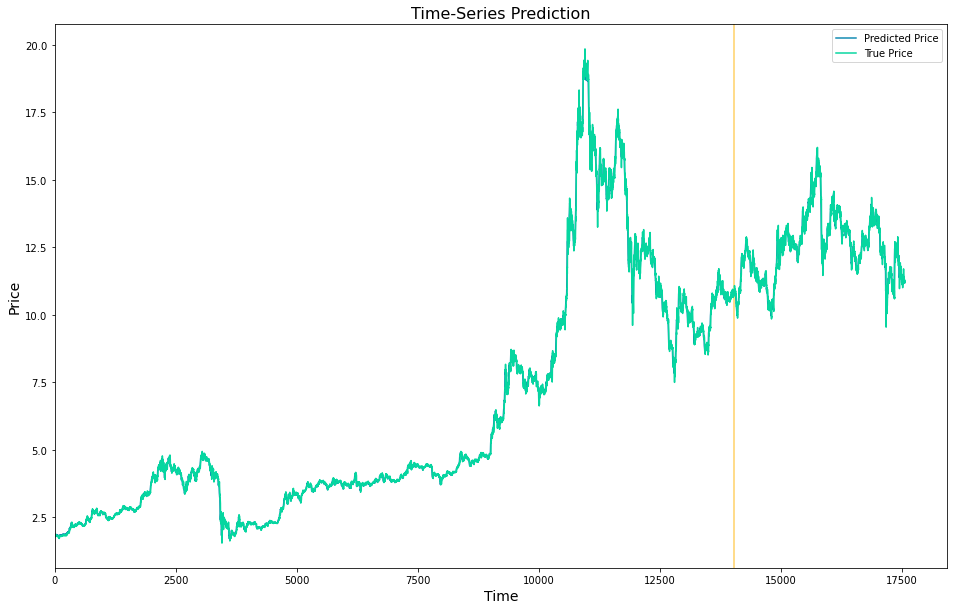

ethereum30m.csv
Epoch: 0, loss: 0.25872
Epoch: 100, loss: 0.00007
Epoch: 200, loss: 0.00005
Epoch: 300, loss: 0.00005
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00005
Epoch: 600, loss: 0.00004
Epoch: 700, loss: 0.00004
Epoch: 800, loss: 0.00004
Epoch: 900, loss: 0.00004
% positive:  0.5007120478496155
% negative:  0.4992879521503845
% neutral:  0.0
positive correct:  0.5386803185437997
negative correct:  0.47746719908727897
0.5081173454856166


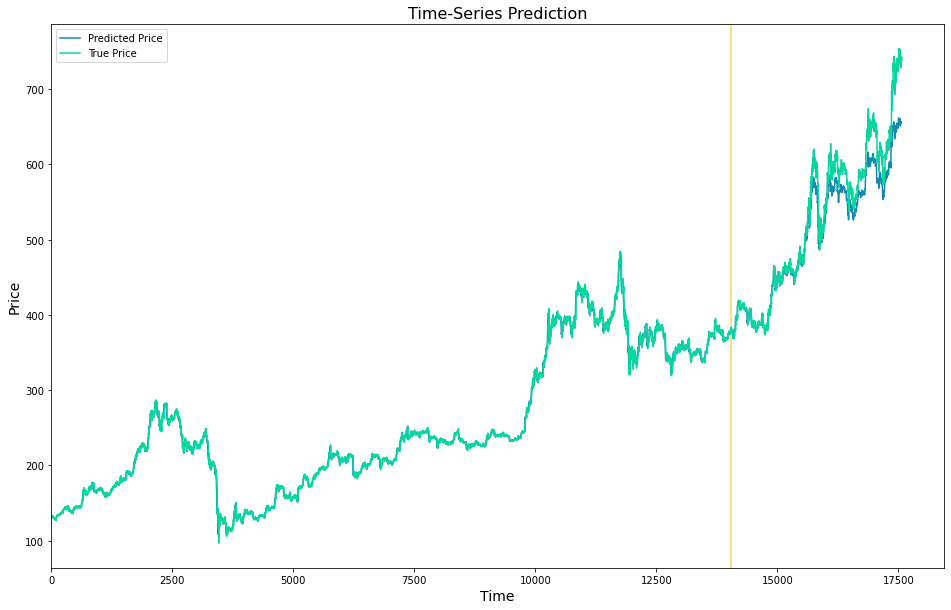

litecoin30m.csv
Epoch: 0, loss: 0.23427
Epoch: 100, loss: 0.00012
Epoch: 200, loss: 0.00008
Epoch: 300, loss: 0.00007
Epoch: 400, loss: 0.00007
Epoch: 500, loss: 0.00006
Epoch: 600, loss: 0.00006
Epoch: 700, loss: 0.00006
Epoch: 800, loss: 0.00005
Epoch: 900, loss: 0.00005
% positive:  0.49416120763315297
% negative:  0.505838792366847
% neutral:  0.0
positive correct:  0.5596541786743516
negative correct:  0.5016891891891891
0.53033323839362


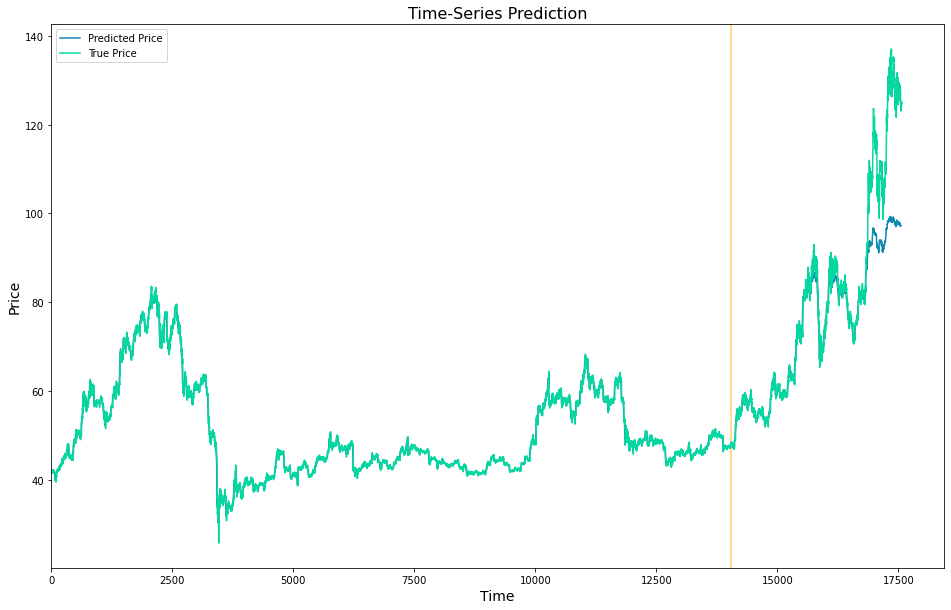

ripple30m.csv
Epoch: 0, loss: 0.02010
Epoch: 100, loss: 0.00003
Epoch: 200, loss: 0.00003
Epoch: 300, loss: 0.00003
Epoch: 400, loss: 0.00003
Epoch: 500, loss: 0.00003
Epoch: 600, loss: 0.00002
Epoch: 700, loss: 0.00002
Epoch: 800, loss: 0.00002
Epoch: 900, loss: 0.00002
% positive:  0.4750783252634577
% negative:  0.5249216747365423
% neutral:  0.0
positive correct:  0.5623501199040767
negative correct:  0.5008138903960934
0.5300484192537739


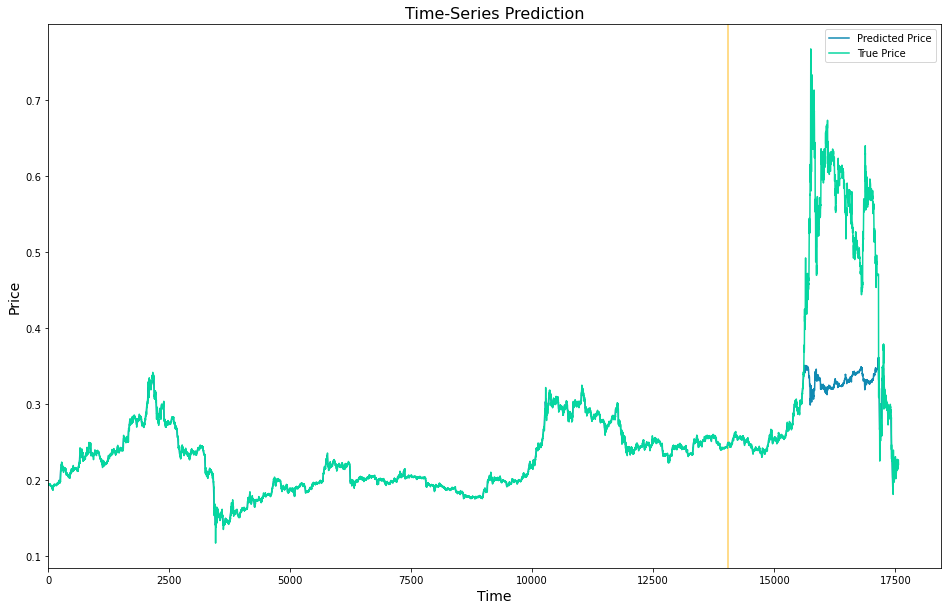

stellar30m.csv
Epoch: 0, loss: 0.01965
Epoch: 100, loss: 0.00005
Epoch: 200, loss: 0.00005
Epoch: 300, loss: 0.00005
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00004
Epoch: 600, loss: 0.00004
Epoch: 700, loss: 0.00004
Epoch: 800, loss: 0.00003
Epoch: 900, loss: 0.00002
% positive:  0.4878951865565366
% negative:  0.5121048134434634
% neutral:  0.0
positive correct:  0.6053706946876825
negative correct:  0.5667408231368187
0.5855881515237824


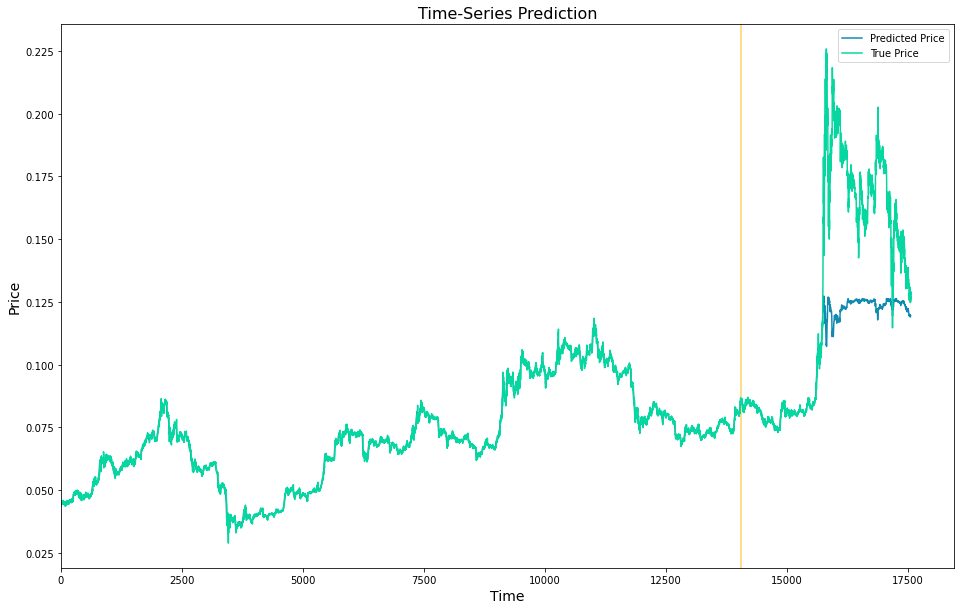

In [13]:
dir_path = "datatest/"
file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
#file_list = [f for f in listdir() if isfile(f)]

file_endings = ["5m.csv", "hourly.csv", "daily.csv", "2h", "30m"]

# FIXME: move to each fileending?
# im going to start with just 5m
file_ending = file_endings[4]
results = []
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  print(filename)
  
  df = pd.read_csv(dir_path + filename)
  # remove unused columns
  exclude_cols = [1]
  df = df.iloc[:, ~df.columns.isin(df.columns[exclude_cols])]

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  df_x_ss = ss.transform(df.iloc[:, :1]) #old transformers

  df_x_2d = []
  for index in range(len(df_x_ss) - look_back):
    df_x_2d.append(df_x_ss[index: index + look_back])
  df_y_mm = mm.transform(df.iloc[:, -1:]) #old transformers

  df_x_2d = np.array(df_x_2d)
  df_x_ss = Variable(torch.Tensor(df_x_2d)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))

  #reshaping the dataset
  #df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

  #print(df_x_ss.size())
  #print(df_y_mm.size())

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation
  #print(df.iloc[cutoff:].priceDirection.reset_index(drop=True))

  accuracy = classify(data_predict[cutoff:], df.iloc[cutoff:].priceDirection.reset_index(drop=True))
  print(accuracy)
  dataY_plot = mm.inverse_transform(dataY_plot)

  plot_name = f"{crypto_name}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  #model_name = f"{crypto_name}.pth"
  #torch.save(lstm.state_dict(), model_name)

  results.append([filename, num_epochs, learning_rate, accuracy])

In [14]:
resultsdf = pd.DataFrame(results)
print("input size: ", input_size)
print("epochs: ", num_epochs)
print("learning rate: ", learning_rate)
print("hidden size: ", hidden_size)
print("look back: ", look_back)
print(resultsdf)

input size:  1
epochs:  1000
learning rate:  0.01
hidden size:  16
look back:  12
                     0     1     2         3
0  binance-coin30m.csv  1000  0.01  0.636001
1  bitcoin-cash30m.csv  1000  0.01  0.583025
2       bitcoin30m.csv  1000  0.01  0.502421
3       cardano30m.csv  1000  0.01  0.548277
4     chainlink30m.csv  1000  0.01  0.542580
5      ethereum30m.csv  1000  0.01  0.508117
6      litecoin30m.csv  1000  0.01  0.530333
7        ripple30m.csv  1000  0.01  0.530048
8       stellar30m.csv  1000  0.01  0.585588
